# RQ1_new — analysis

Reads from `clean_data/<model>.csv`, built by `build_clean_dataset.py` — **only from rounds verified round-by-round to not have the silent-no-contention bug found 2026-08-05**, never from everything collected so far. See `clean_data/MANIFEST.json` for exactly which rounds went in and why; `model2` and `model3` (sib_cfs) currently have nothing valid pooled yet — every existing round of both predates the fix and showed the bug. Re-run `build_clean_dataset.py` after collecting/verifying new rounds.

**Definitions** (raw jobs.csv columns → derived): `D`=period, `Q`=round(U·P), `bound`=max(1, 2(P−Q)), `alpha`=C/Q, `delta`=(R−C)/bound, `R/D`=R/P. Raw (non-normalized) counterparts shown alongside: `C_cputime_us` itself, and `R_wall_us − C_cputime_us` (added latency, µs).

In [10]:
import sys

sys.path.append("/home/silvia/Documents/GraduationProject/research-questions/RQ1_new/analysis")

import analysis_lib as al
import pandas as pd
pd.set_option("display.width", 140)

MODELS = ["model1", "model3-w2", "model3-w3", "model3-w4"]  # model2, model3 excluded: nothing valid yet
data = {m: al.load_model(m) for m in MODELS}

## Section A — pooled dataset (all U together)

### A.1 Basic descriptives

In [11]:
for m in MODELS:
    if data[m].empty: continue
    print(f"=== {m} ===")
    display(al.descriptives_table(data[m]))

=== model1 ===


,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,R (response),200000,38942.2,19935.4,6856.3,41971.9,67335.1,68352.2,72534.1,652541.4
1,soft,C (execution),200000,38867.4,19875.9,6849.0,41899.0,67310.0,68312.9,71317.8,103283.2
2,tight,R (response),200000,4020.5,2053.7,701.6,4298.2,6864.6,6929.6,10028.7,35576.1
3,tight,C (execution),200000,4000.6,2038.9,694.3,4263.0,6847.5,6913.7,7003.2,10948.4


=== model3-w2 ===


,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,R (response),50000,139101.2,26836.8,101979.9,134501.9,204623.5,206204.1,209982.9,226794.7
1,soft,C (execution),50000,85261.6,40856.2,12857.6,92425.3,146199.0,153536.0,156782.1,166970.5
2,tight,R (response),50000,12428.6,1832.7,4444.4,12367.9,14670.8,20136.4,23697.5,50514.4
3,tight,C (execution),50000,7950.2,3957.6,1325.4,8388.9,14026.9,14624.6,17337.0,47879.4


=== model3-w3 ===


,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,R (response),200000,38593.4,19662.2,6852.7,41623.7,66464.3,68348.0,69064.8,100078.3
1,soft,C (execution),200000,38495.8,19703.9,6788.9,40677.5,66437.7,68315.7,69012.1,72314.8
2,tight,R (response),200000,3911.4,1997.8,708.1,3978.2,6752.8,6844.4,6986.6,40035.8
3,tight,C (execution),200000,3886.8,1991.2,693.8,3951.0,6731.9,6823.7,6929.6,8968.8


=== model3-w4 ===


,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,R (response),200000,39496.3,20177.9,7031.2,42406.5,68001.0,68676.9,100222.1,122211.0
1,soft,C (execution),200000,39340.7,20125.4,6869.9,42319.8,67964.2,68625.0,74155.7,108158.2
2,tight,R (response),160000,3826.6,2143.4,710.3,3655.9,6867.4,7119.5,10741.4,38007.3
3,tight,C (execution),160000,3777.3,2097.5,694.3,3628.2,6828.6,7029.8,8505.3,12158.5


### A.2 Distribution of R and C over U
Boxplots, not a single collapsed histogram — R and C aren't comparable across different U cells (different Q/period), so the shape needs to be shown *per U*, not pooled across it.

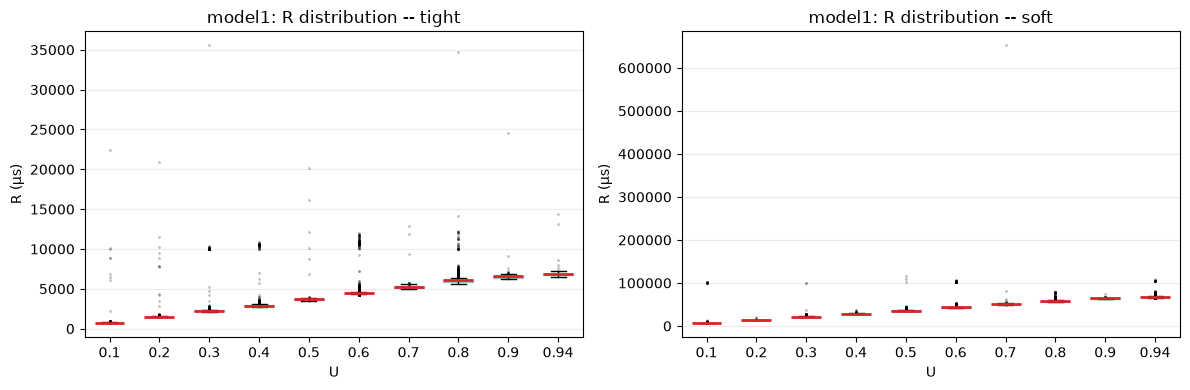

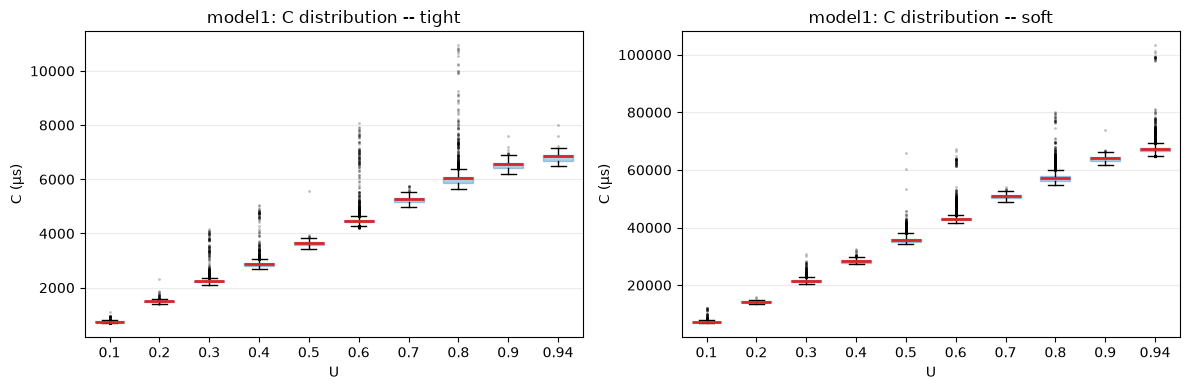

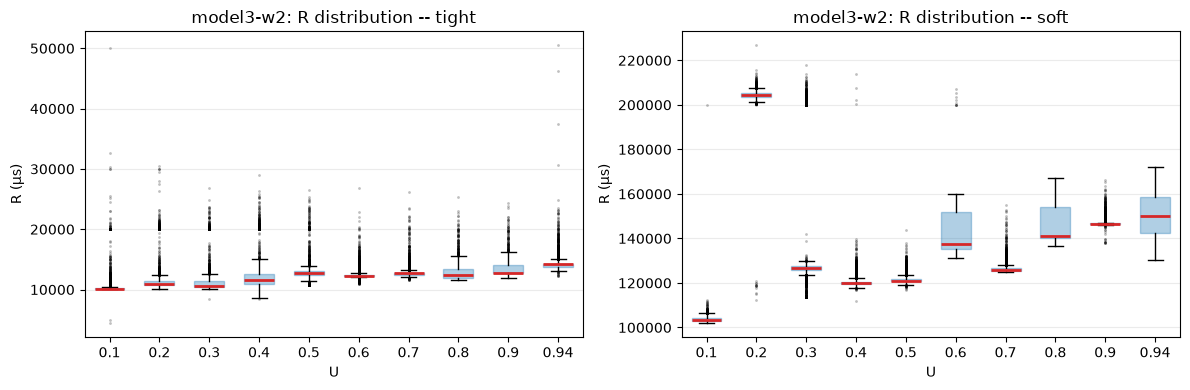

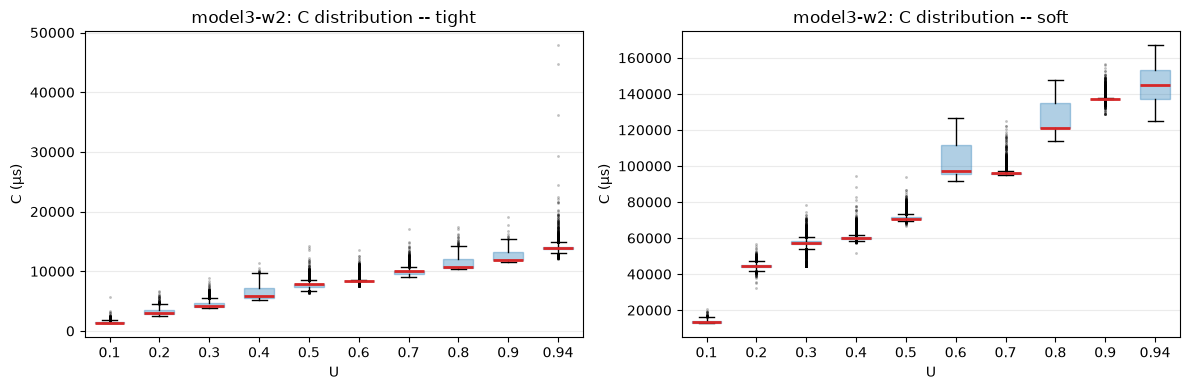

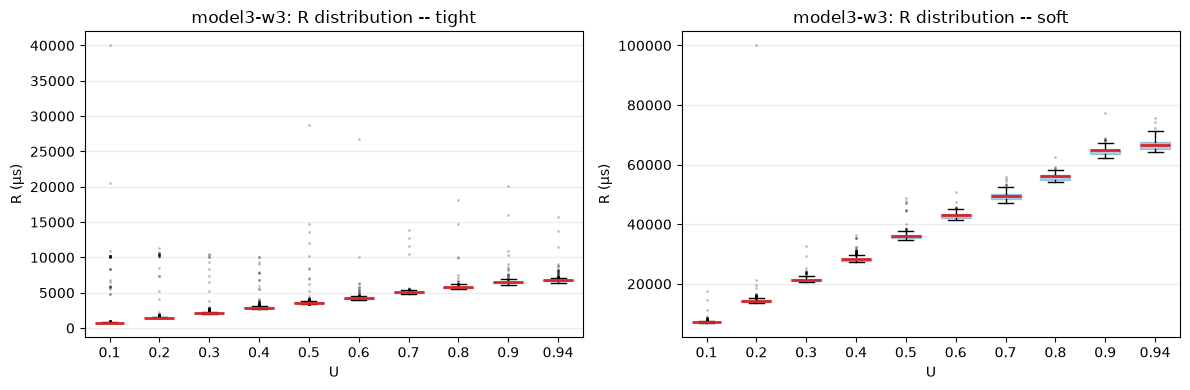

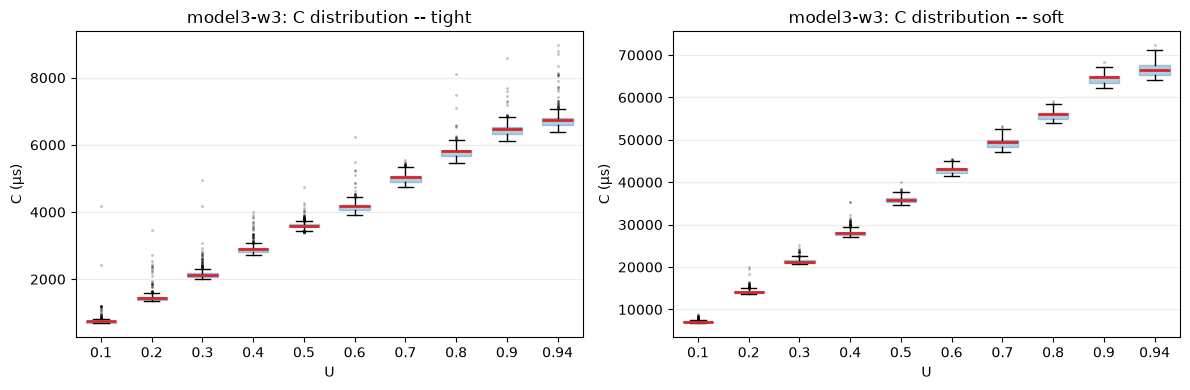

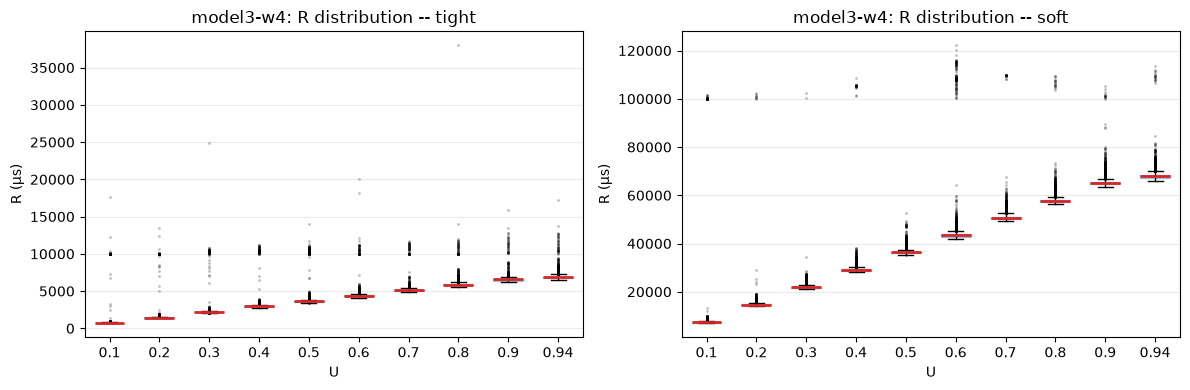

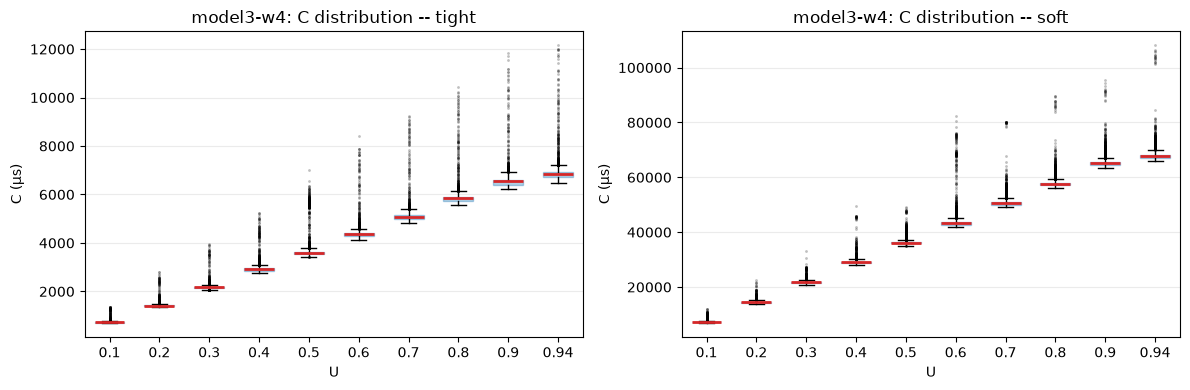

In [12]:
for m in MODELS:
    if data[m].empty: continue
    al.distribution_over_u(data[m], "R_wall_us", "R (\u00b5s)", f"{m}: R distribution")
    al.distribution_over_u(data[m], "C_cputime_us", "C (\u00b5s)", f"{m}: C distribution")

### A.3 Budget overrun (alpha > 1)
How often execution ALONE exceeds the reservation's own budget — independent of whether the job also missed its deadline.

In [13]:
for m in MODELS:
    if data[m].empty: continue
    print(f"=== {m} ===")
    display(al.budget_overrun_table(data[m]))

=== model1 ===


,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,20000,0.0006,0.726,0.767,1.213
1,soft,0.20,20000,0.0000,0.710,0.727,0.802
2,soft,0.30,20000,0.0001,0.717,0.752,1.024
3,soft,0.40,20000,0.0000,0.708,0.721,0.811
4,soft,0.50,20000,0.0001,0.712,0.763,1.317
5,soft,0.60,20000,0.0017,0.718,0.783,1.120
6,soft,0.70,20000,0.0000,0.730,0.736,0.773
7,soft,0.80,20000,0.0000,0.716,0.762,1.000
8,soft,0.90,20000,0.0000,0.713,0.718,0.820
9,soft,0.94,20000,0.0008,0.716,0.754,1.099


=== model3-w2 ===


,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,5000,1.0,1.345,1.577,2.063
1,soft,0.20,5000,1.0,2.235,2.453,2.838
2,soft,0.30,5000,1.0,1.912,2.221,2.619
3,soft,0.40,5000,1.0,1.498,1.736,2.360
4,soft,0.50,5000,1.0,1.415,1.587,1.877
5,soft,0.60,5000,1.0,1.622,1.949,2.114
6,soft,0.70,5000,1.0,1.369,1.522,1.787
7,soft,0.80,5000,1.0,1.516,1.738,1.849
8,soft,0.90,5000,1.0,1.525,1.617,1.742
9,soft,0.94,5000,1.0,1.541,1.667,1.776


=== model3-w3 ===


,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,20000,0.0000,0.704,0.742,0.902
1,soft,0.20,20000,0.0000,0.701,0.732,1.001
2,soft,0.30,20000,0.0000,0.706,0.733,0.841
3,soft,0.40,20000,0.0000,0.700,0.721,0.886
4,soft,0.50,20000,0.0000,0.716,0.736,0.799
5,soft,0.60,20000,0.0000,0.719,0.731,0.760
6,soft,0.70,20000,0.0000,0.706,0.731,0.760
7,soft,0.80,20000,0.0000,0.701,0.713,0.740
8,soft,0.90,20000,0.0000,0.720,0.730,0.759
9,soft,0.94,20000,0.0000,0.707,0.734,0.769


=== model3-w4 ===


,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,20000,0.0016,0.720,0.769,1.199
1,soft,0.20,20000,0.0004,0.725,0.752,1.127
2,soft,0.30,20000,0.0001,0.724,0.749,1.099
3,soft,0.40,20000,0.0010,0.726,0.773,1.236
4,soft,0.50,20000,0.0000,0.724,0.774,0.986
5,soft,0.60,20000,0.0051,0.723,0.810,1.373
6,soft,0.70,20000,0.0008,0.724,0.781,1.148
7,soft,0.80,20000,0.0008,0.722,0.777,1.122
8,soft,0.90,20000,0.0006,0.724,0.774,1.059
9,soft,0.94,20000,0.0008,0.723,0.774,1.151


### A.4 Round-to-round stability (QA check, keep this)
Straight from the included rounds' own raw data, not the pooled file — this is the exact check that caught the coin-flip bug. A round whose numbers don't match its siblings at the same U is the tell; pooling alone hides it. Re-check this whenever a new round is added to `clean_data`.

In [14]:
for m in MODELS:
    t = al.round_stability_table(m)
    if t.empty: continue
    print(f"=== {m} ===")
    display(t)

=== model1 ===


model1_round1  model1_round2  model1_round3  model1_round4  C_p50[model1_round1]  C_p50[model1_round2]  C_p50[model1_round3]  \
scale U                                                                                                                                    
soft  0.10         0.0026         0.0000         0.0000         0.0000             7434.4300             7065.8655             7282.3540   
      0.20         0.0000         0.0000         0.0000         0.0000            14446.4250            13967.2060            14112.8245   
      0.30         0.0000         0.0000         0.0000         0.0004            21684.3765            20959.9735            21228.3180   
      0.40         0.0000         0.0000         0.0000         0.0000            28625.6135            27664.4960            28182.5740   
      0.50         0.0006         0.0000         0.0000         0.0000            36662.0490            34715.8340            35338.1050   
      0.60         0.0000         0.0034         0.0000         0.0034            43235.0700            42628.1895            42616.5520   
      0.70         0.0002         0.0000         0.0000         0.0000            51227.5170            49585.3780            51053.2375   
      0.80         0.0000         0.0000         0.0000         0.0000            58551.3980            55375.2120            57153.0870   
      0.90         0.0000         0.0000         0.0000         0.0000            64414.4070            62203.5910            64129.1850   
      0.94         0.0000         0.0000         0.0034         0.0000            67372.6380            65104.0550            68194.9515   
tight 0.10         0.0002         0.0000         0.0002         0.0002              755.4970              731.2620              744.5545   
      0.20         0.0000         0.0002         0.0004         0.0000             1509.9295             1461.7120             1498.6200   
      0.30         0.0000         0.0000         0.0124         0.0002             2258.6450             2186.7960             2261.4010   
      0.40         0.0074         0.0000         0.0000         0.0000             2921.0015             2793.4200             2865.3500   
      0.50         0.0000         0.0002         0.0002         0.0004             3676.2875             3560.8915             3654.6995   
      0.60         0.0000         0.0070         0.0000         0.0066             4460.2485             4419.5960             4432.9885   
      0.70         0.0000         0.0002         0.0000         0.0002             5309.0280             5126.7080             5249.0175   
      0.80         0.0002         0.0002         0.0002         0.0064             6057.7930             5858.9295             5998.6150   
      0.90         0.0000         0.0000         0.0002         0.0000             6592.2035             6365.7760             6530.9380   
      0.94         0.0002         0.0002         0.0000         0.0000             6882.8785             6649.7660             6842.8305   

            C_p50[model1_round4]  
scale U                           
soft  0.10             7225.1150  
      0.20            14299.5625  
      0.30            21910.3115  
      0.40            28487.3775  
      0.50            35753.3180  
      0.60            43592.0795  
      0.70            51219.0010  
      0.80            57320.1330  
      0.90            64243.1560  
      0.94            67252.5890  
tight 0.10              755.4135  
      0.20             1504.8390  
      0.30             2258.2480  
      0.40             2880.0490  
      0.50             3670.8695  
      0.60             4557.9270  
      0.70             5285.9535  
      0.80             6127.8980  
      0.90             6578.9570  
      0.94             6877.5095

=== model3-w2 ===


model3-w2_sib_res_round4  C_p50[model3-w2_sib_res_round4]
scale U                                                              
soft  0.10                    1.0000                       13449.9565
      0.20                    1.0000                       44702.4430
      0.30                    1.0000                       57359.5970
      0.40                    1.0000                       59927.5270
      0.50                    1.0000                       70763.2855
      0.60                    1.0000                       97324.6300
      0.70                    1.0000                       95827.8205
      0.80                    1.0000                      121304.6590
      0.90                    1.0000                      137261.1125
      0.94                    1.0000                      144893.1230
tight 0.10                    0.9996                        1409.0540
      0.20                    1.0000                        2961.8885
      0.30                    0.9998                        4188.1945
      0.40                    0.9996                        5916.3735
      0.50                    1.0000                        7792.5775
      0.60                    1.0000                        8405.5475
      0.70                    1.0000                        9988.9960
      0.80                    1.0000                       10733.7215
      0.90                    1.0000                       11917.9170
      0.94                    1.0000                       13903.1920

=== model3-w3 ===


model3-w3_phys_cfs_round1  model3-w3_phys_cfs_round2  model3-w3_phys_cfs_round3  model3-w3_phys_cfs_round4  \
scale U                                                                                                                  
soft  0.10                     0.0000                     0.0000                     0.0000                     0.0000   
      0.20                     0.0000                     0.0000                     0.0002                     0.0000   
      0.30                     0.0000                     0.0000                     0.0000                     0.0000   
      0.40                     0.0000                     0.0000                     0.0000                     0.0000   
      0.50                     0.0000                     0.0000                     0.0000                     0.0000   
      0.60                     0.0000                     0.0000                     0.0000                     0.0000   
      0.70                     0.0000                     0.0000                     0.0000                     0.0000   
      0.80                     0.0000                     0.0000                     0.0000                     0.0000   
      0.90                     0.0000                     0.0000                     0.0000                     0.0000   
      0.94                     0.0000                     0.0000                     0.0000                     0.0000   
tight 0.10                     0.0002                     0.0002                     0.0030                     0.0002   
      0.20                     0.0000                     0.0000                     0.0024                     0.0002   
      0.30                     0.0000                     0.0000                     0.0006                     0.0002   
      0.40                     0.0000                     0.0000                     0.0002                     0.0002   
      0.50                     0.0000                     0.0000                     0.0006                     0.0004   
      0.60                     0.0002                     0.0000                     0.0002                     0.0000   
      0.70                     0.0002                     0.0002                     0.0002                     0.0002   
      0.80                     0.0002                     0.0000                     0.0004                     0.0000   
      0.90                     0.0004                     0.0002                     0.0002                     0.0000   
      0.94                     0.0000                     0.0004                     0.0000                     0.0002   

            C_p50[model3-w3_phys_cfs_round1]  C_p50[model3-w3_phys_cfs_round2]  C_p50[model3-w3_phys_cfs_round3]  \
scale U                                                                                                            
soft  0.10                         6997.2275                         6978.8740                         7243.1740   
      0.20                        13914.4920                        13914.0130                        14409.2370   
      0.30                        20946.6850                        20996.8605                        21686.3400   
      0.40                        27452.1945                        27874.3825                        28403.2100   
      0.50                        35123.3010                        35614.8610                        36351.4730   
      0.60                        41925.0535                        43320.6940                        43398.6115   
      0.70                        47937.4240                        49544.6055                        50550.6220   
      0.80                        54406.7215                        56278.8705                        56343.1355   
      0.90                        62944.4370                        64960.4625                        65084.8800   
      0.94                        64668.0680       

=== model3-w4 ===


model3-w4_phys_res_round1  model3-w4_phys_res_round2  model3-w4_phys_res_round3  model3-w4_phys_res_round4  \
scale U                                                                                                                  
soft  0.10                     0.0000                     0.0064                     0.0000                     0.0000   
      0.20                     0.0000                     0.0014                     0.0000                     0.0002   
      0.30                     0.0000                     0.0004                     0.0000                     0.0000   
      0.40                     0.0000                     0.0040                     0.0002                     0.0000   
      0.50                     0.0000                     0.0000                     0.0000                     0.0000   
      0.60                     0.0000                     0.0204                     0.0000                     0.0000   
      0.70                     0.0000                     0.0034                     0.0000                     0.0000   
      0.80                     0.0000                     0.0034                     0.0000                     0.0000   
      0.90                     0.0000                     0.0026                     0.0000                     0.0000   
      0.94                     0.0000                     0.0034                     0.0000                     0.0000   
tight 0.10                     0.0002                     0.0006                     0.0136                     0.0002   
      0.20                     0.0002                     0.0000                     0.0088                     0.0002   
      0.30                     0.0000                        NaN                     0.0080                     0.0002   
      0.40                     0.0000                        NaN                     0.0134                     0.0000   
      0.50                     0.0000                        NaN                     0.0702                     0.0002   
      0.60                     0.0002                        NaN                     0.0098                     0.0002   
      0.70                     0.0002                        NaN                     0.0100                     0.0000   
      0.80                     0.0004                        NaN                     0.0100                     0.0002   
      0.90                     0.0004                        NaN                     0.0074                     0.0000   
      0.94                     0.0002                        NaN                     0.0078                     0.0004   

            C_p50[model3-w4_phys_res_round1]  C_p50[model3-w4_phys_res_round2]  C_p50[model3-w4_phys_res_round3]  \
scale U                                                                                                            
soft  0.10                         7093.8130                         7240.2190                         7322.7750   
      0.20                        14204.6810                        14533.3645                        14617.0185   
      0.30                        21276.9755                        21765.8170                        21903.6300   
      0.40                        28550.3085                        29233.5550                        28819.3490   
      0.50                        36208.8890                        36336.6630                        35414.8370   
      0.60                        42681.4685                        43736.8010                        42938.9040   
      0.70                        49772.8320                        50963.1090                        50432.6640   
      0.80                        56740.6215                        58078.7865                        57866.8260   
      0.90                        63990.0930                        65432.9575                        65339.4295   
      0.94                        66771.1235       

### A.5 Burst of missed jobs (longest consecutive run)
Temporal statistic — computed per round on that round's own job-order sequence, then MAXED across included rounds. Never concatenate raw sequences across rounds for this one (see `analysis_lib.longest_miss_run_table` docstring).

In [ ]:
for m in MODELS:
    t = al.longest_miss_run_table(m)
    if t.empty: continue
    print(f"=== {m} ===")
    display(t)

=== model1 ===


,scale,U,longest_consecutive_miss_run
0,soft,0.10,1
1,soft,0.20,0
2,soft,0.30,1
3,soft,0.40,0
4,soft,0.50,3
5,soft,0.60,1
6,soft,0.70,1
7,soft,0.80,0
8,soft,0.90,0
9,soft,0.94,1


=== model3-w2 ===


,scale,U,longest_consecutive_miss_run
0,soft,0.10,5000
1,soft,0.20,5000
2,soft,0.30,5000
3,soft,0.40,5000
4,soft,0.50,5000
5,soft,0.60,5000
6,soft,0.70,5000
7,soft,0.80,5000
8,soft,0.90,5000
9,soft,0.94,5000


=== model3-w3 ===


,scale,U,longest_consecutive_miss_run
0,soft,0.10,0
1,soft,0.20,1
2,soft,0.30,0
3,soft,0.40,0
4,soft,0.50,0
5,soft,0.60,0
6,soft,0.70,0
7,soft,0.80,0
8,soft,0.90,0
9,soft,0.94,0


=== model3-w4 ===


,scale,U,longest_consecutive_miss_run
0,soft,0.10,1
1,soft,0.20,1
2,soft,0.30,1
3,soft,0.40,1
4,soft,0.50,0
5,soft,0.60,91
6,soft,0.70,1
7,soft,0.80,1
8,soft,0.90,1
9,soft,0.94,1


**On the isolated burst in model3-w4 (physical placement, reserved competitor), soft scale, U=0.6:**

One of the four collected rounds for this cell shows a run of 91 consecutive
deadline misses, an outlier against the near-zero miss rate this arm shows
everywhere else. Inspection of the raw per-job data shows this is not a
failure of the physical-placement isolation the arm is designed to test: the
target's execution time (`C_cputime_us`) during the affected jobs stays close
to its normal value, and `dispatch_latency_us` (time from release to actual
start) is unaffected -- the target is not being blocked from starting, and it
is not executing more slowly once running.

Instead, the delay appears *within* execution: `mid_job_preempt_us` --
computed as (finish − start) − C, i.e. wall-clock time between start and
finish not accounted for by measured CPU time -- jumps from a baseline of
roughly 1-2µs to a consistent ~39.7ms (std ≈ 9µs across the affected jobs)
for exactly this window, accompanied by a genuine OS-reported involuntary
context switch (`nonvol_ctxt=1`, versus 0 in unaffected jobs). This value is
close to P−Q for this cell (100,000µs period − 40,000µs budget at U=0.6 ≈
40,000µs remaining), consistent with the target's thread being blocked by the
kernel's own real-time bandwidth throttling (the `cpu.rt_runtime_us` cgroup
mechanism used to seed CBS-style budgets on this cluster) until the start of
the next scheduling period, rather than with contention from the co-located
competitor, which remains on a separate physical core throughout.

The same low-frequency pattern (affecting well under 1% of jobs) is present
across the solo baseline (model1) and the other physical-placement arm
(model3-w3) as well, which rules out the reserved competitor as the cause:
these are isolated instances of the reservation's own kernel-level budget
enforcement occasionally engaging, not a breakdown of the physical-core
isolation this arm is designed to demonstrate. The round in question is
otherwise consistent with the other three rounds collected for this arm and
is retained in the pooled dataset; this episode is noted here rather than
excluded, since it reflects a real (if rare) system behavior rather than a
measurement artifact.

### A.6 p99 / p999 safe margins
The empirical "how far can you provision before this breaks the deadline" answer — largest U at which p99/p999 of R/D stays under 1.

In [16]:
for m in MODELS:
    if data[m].empty: continue
    print(f"=== {m} ===")
    display(al.safe_margin_table(data[m]))

=== model1 ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.596
1,tight,0.94,0.299


=== model3-w2 ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.1,0.1
1,tight,0.1,0.1


=== model3-w3 ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.94
1,tight,0.94,0.94


=== model3-w4 ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.940,0.399
1,tight,0.493,0.100


## Section B — per utilization (U)

### B.1 alpha (C/Q, normalized) and raw C, vs U
Shaded band = p10–p90 (stability at that U); dashed = p99. Reference line at alpha=1 (=1 line: guarantee-hold boundary for the normalized panel; raw-C panel has no single universal reference since Q itself changes with U).

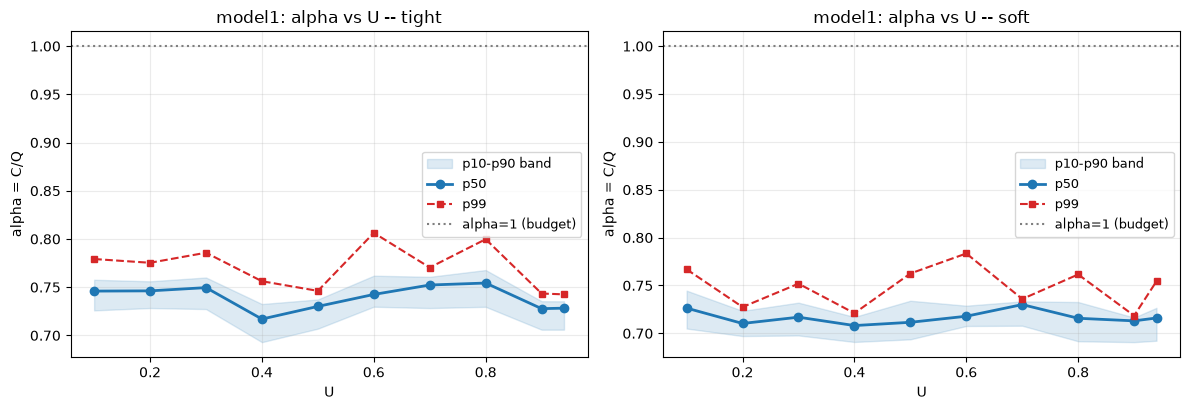

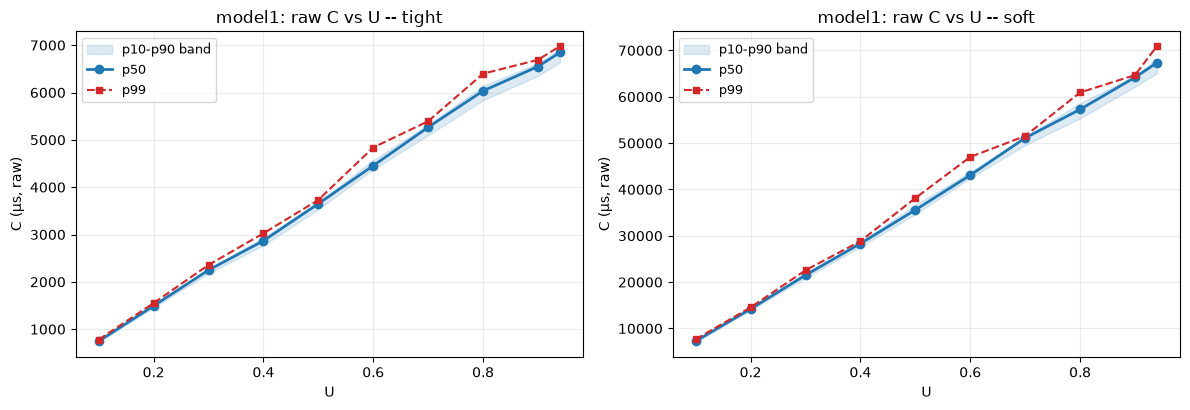

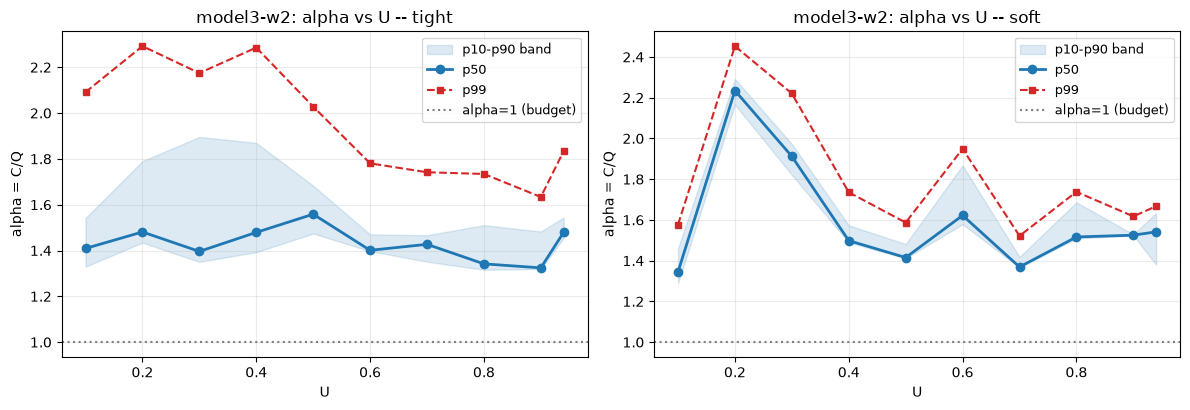

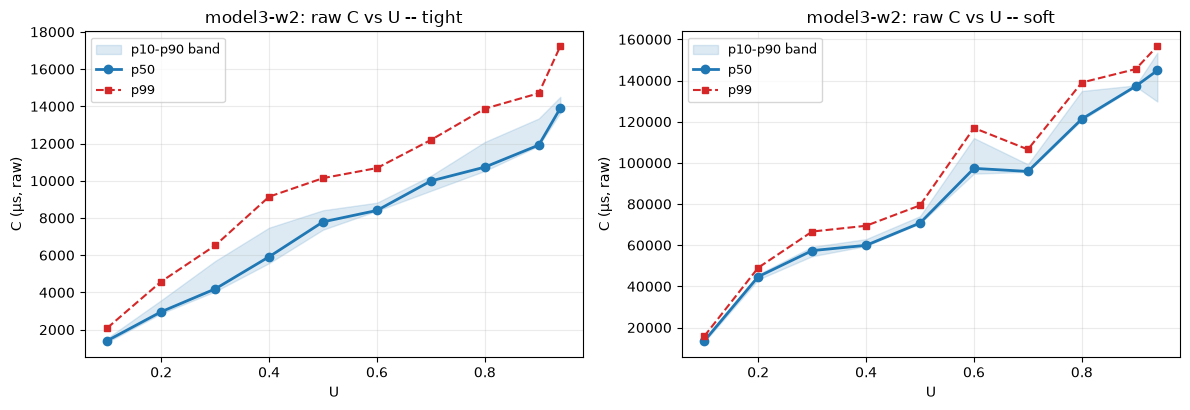

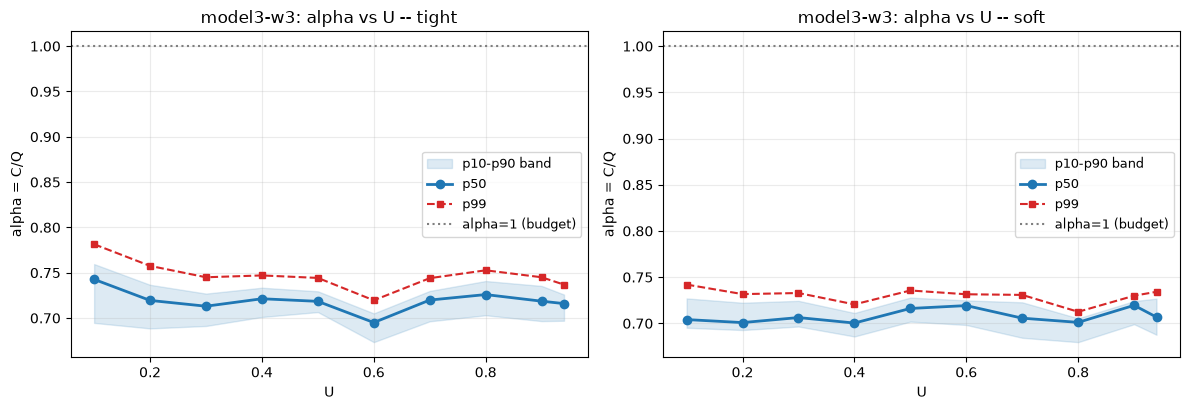

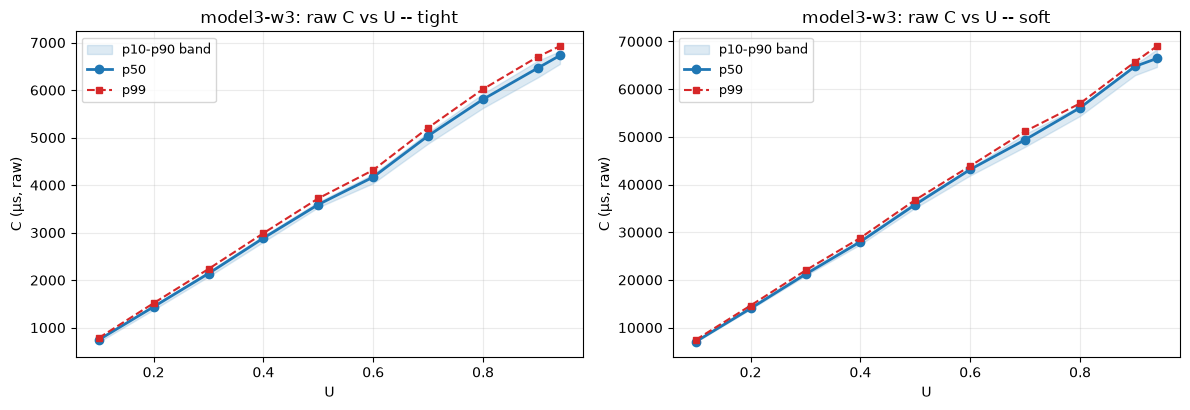

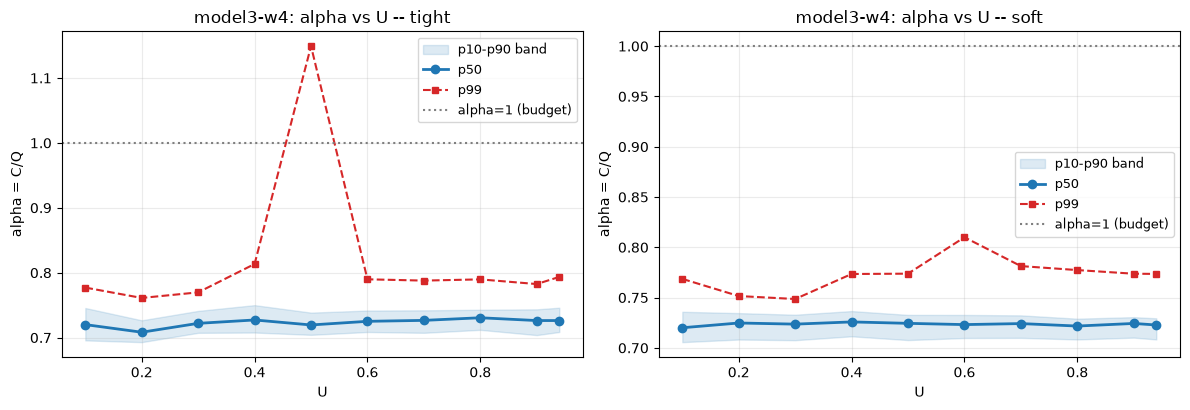

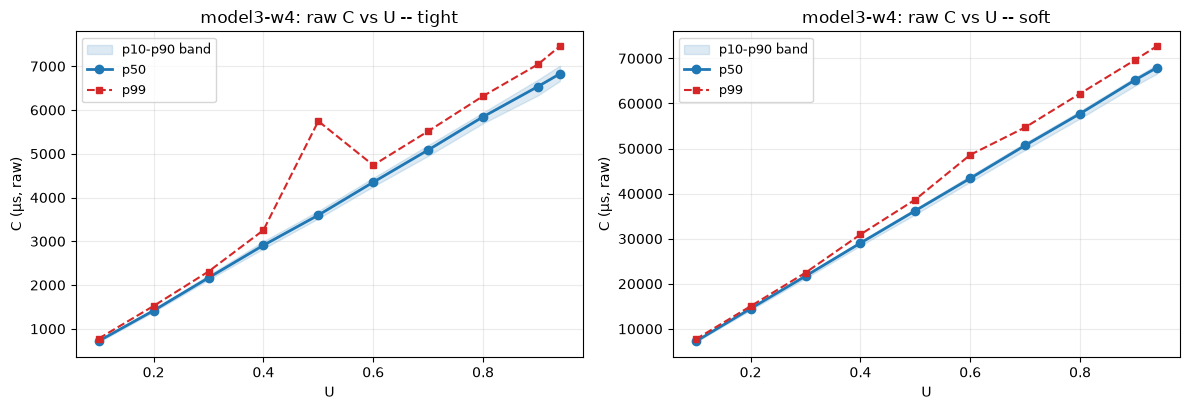

In [17]:
for m in MODELS:
    if data[m].empty: continue
    al.plot_vs_u(data[m], "alpha", "alpha = C/Q", f"{m}: alpha vs U", hline=1, hline_label="alpha=1 (budget)")
    al.plot_vs_u(data[m], "C_cputime_us", "C (\u00b5s, raw)", f"{m}: raw C vs U")

### B.2 delta (normalized) and raw added latency (R−C), vs U

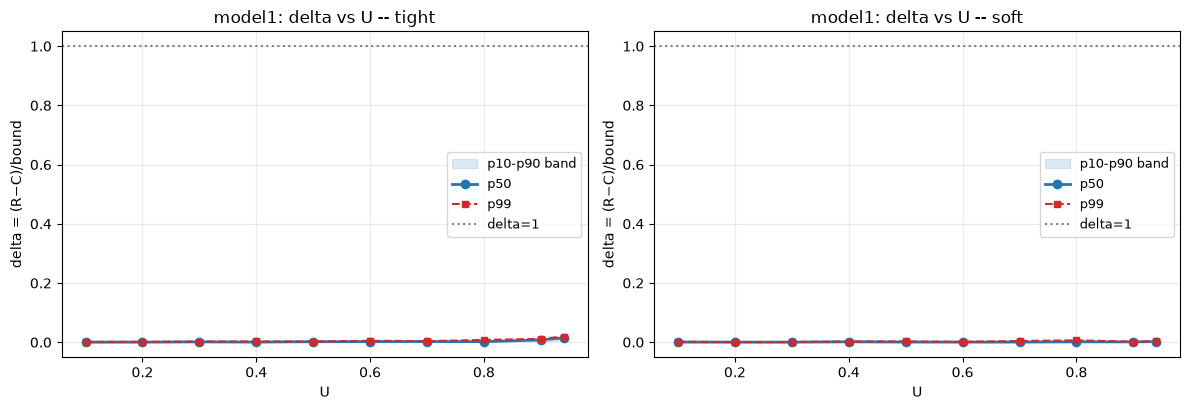

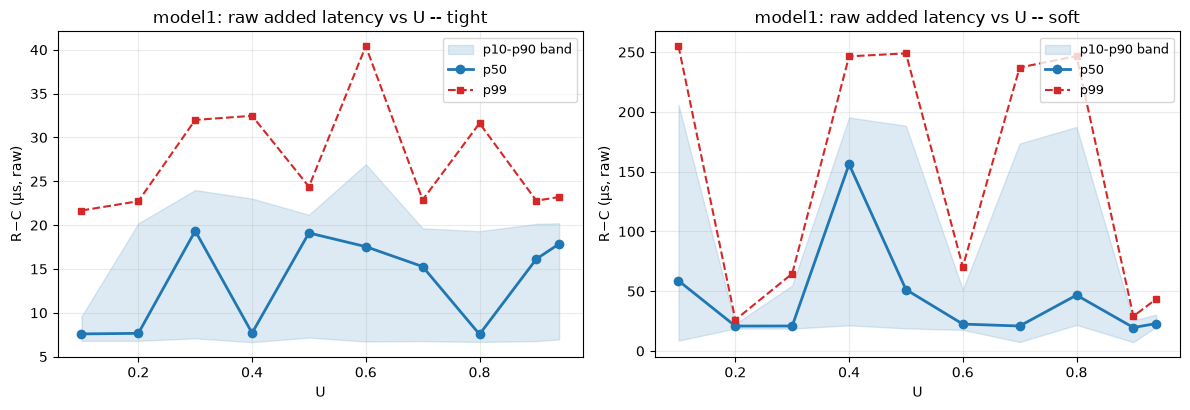

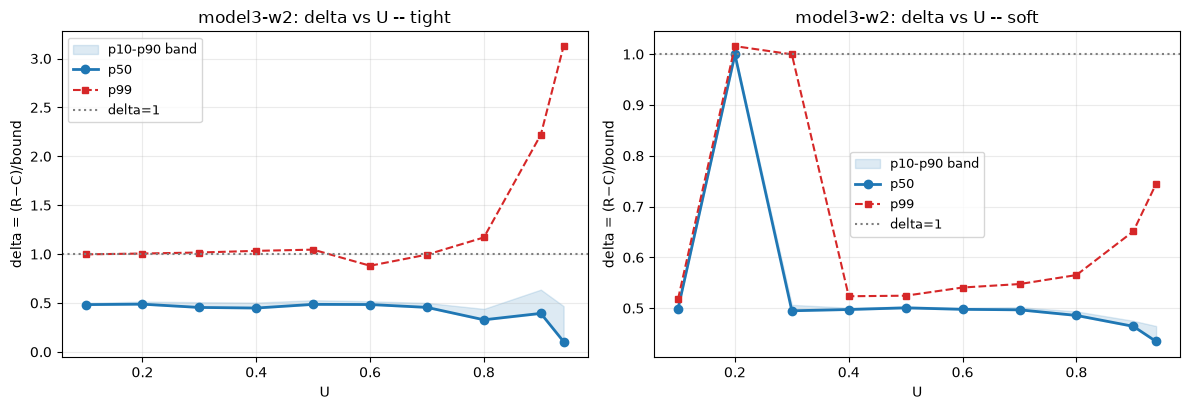

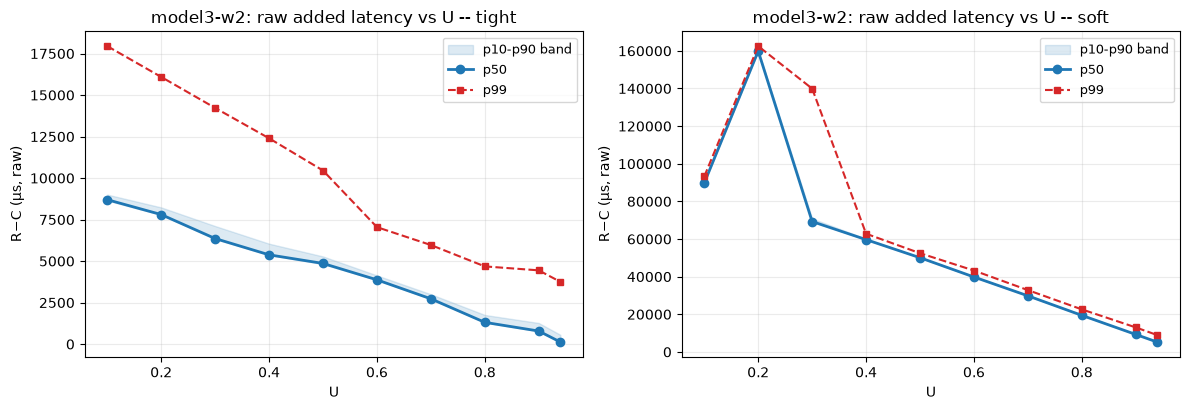

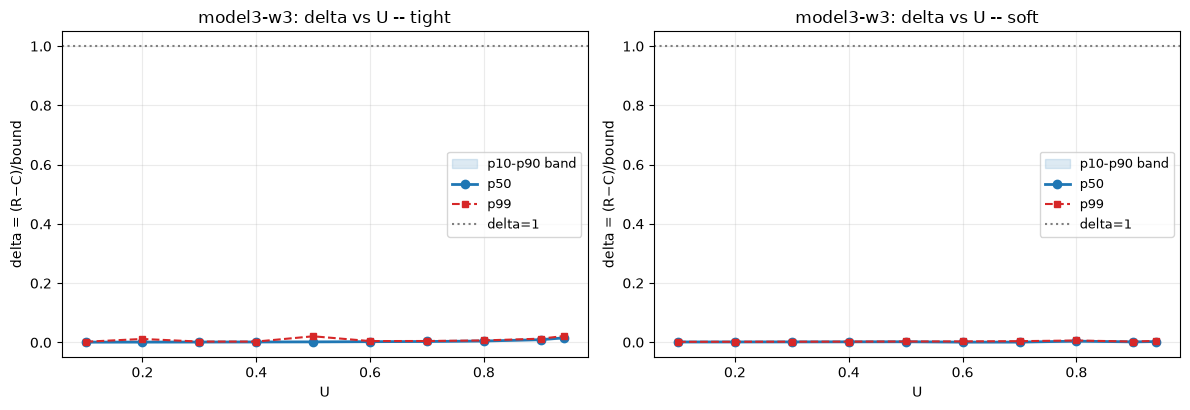

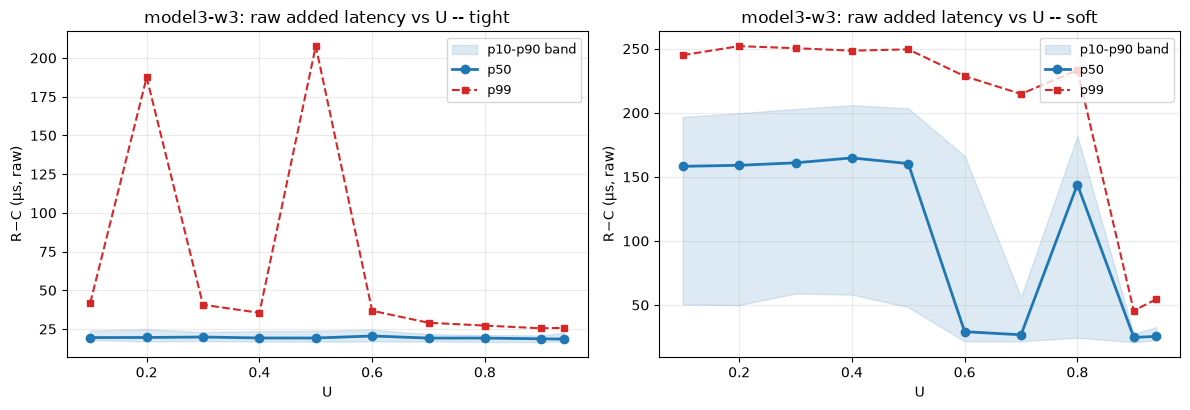

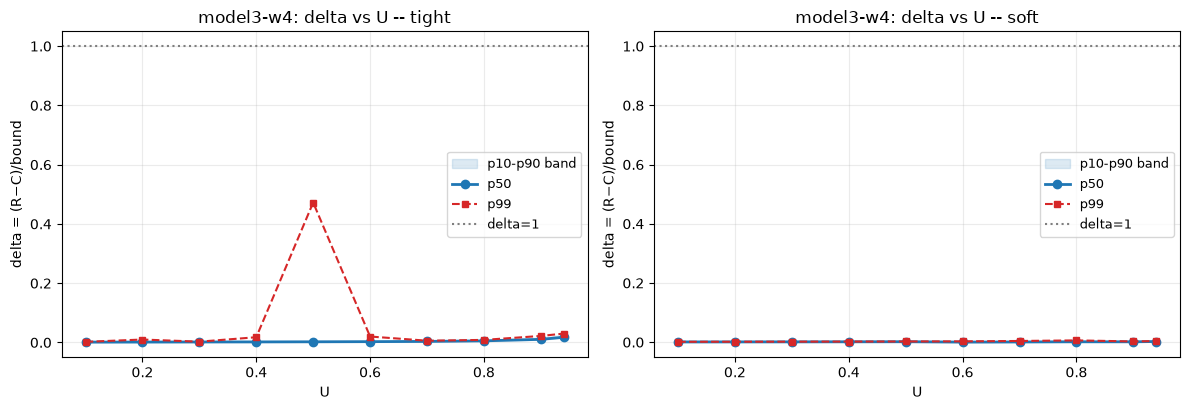

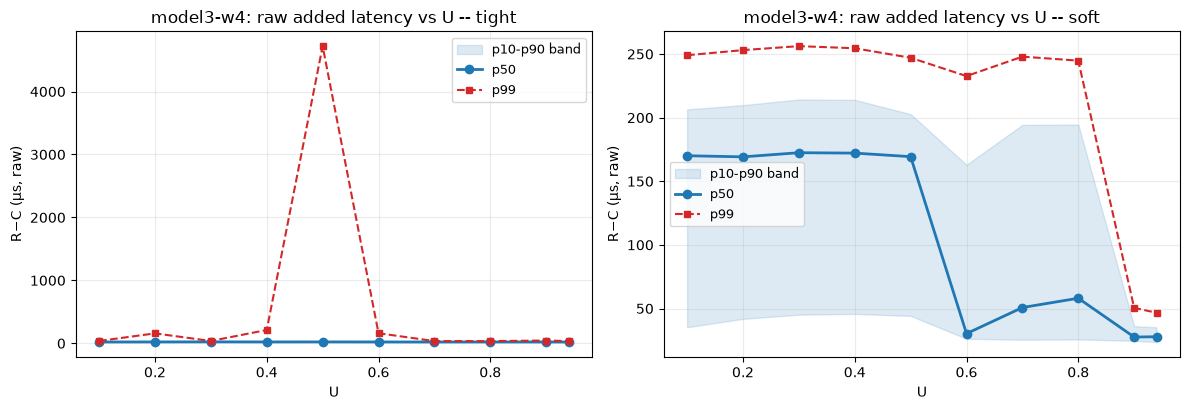

In [18]:
for m in MODELS:
    if data[m].empty: continue
    al.plot_vs_u(data[m], "delta", "delta = (R−C)/bound", f"{m}: delta vs U", hline=1, hline_label="delta=1")
    al.plot_vs_u(data[m], "added_latency_us", "R−C (\u00b5s, raw)", f"{m}: raw added latency vs U")

### B.3 Deadline miss rate vs U

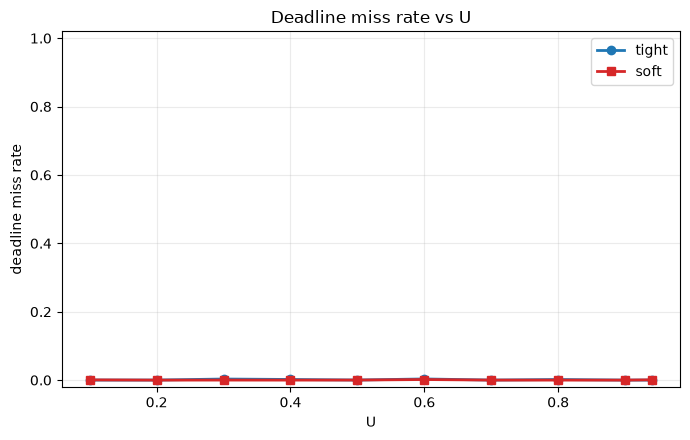

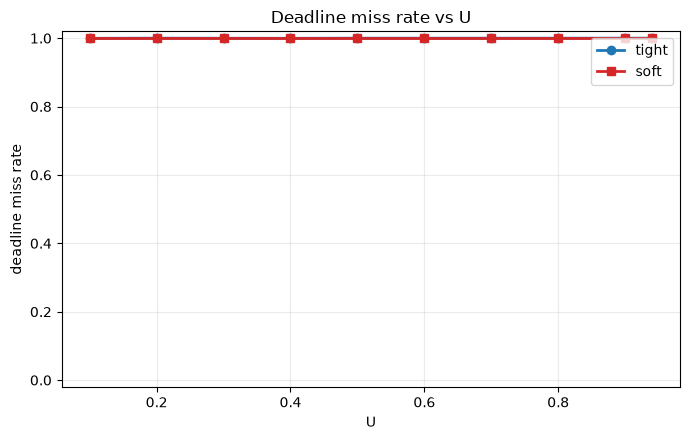

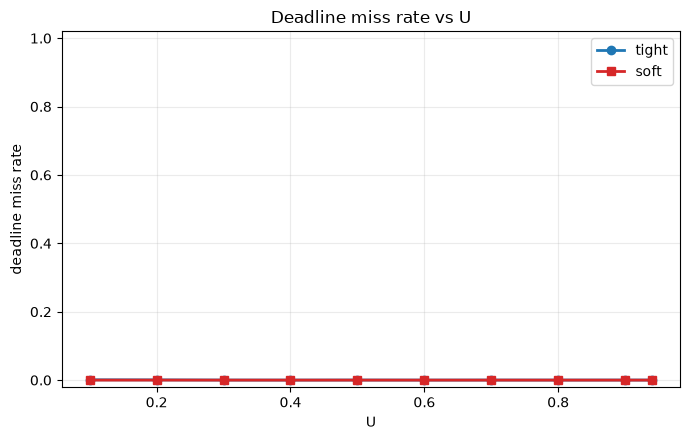

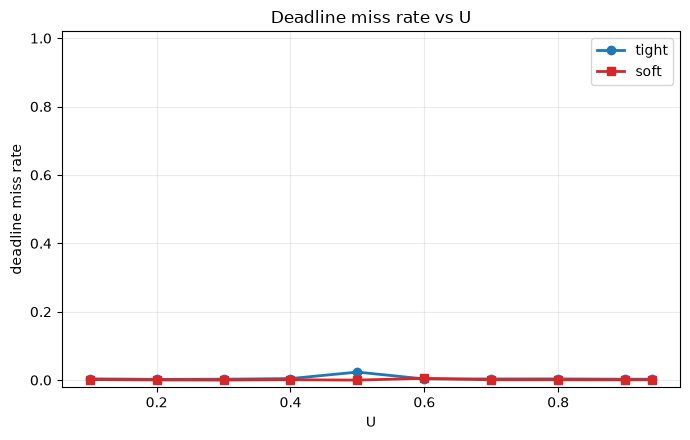

In [19]:
for m in MODELS:
    if data[m].empty: continue
    al.miss_rate_vs_u(data[m])

### B.4 p50 / p99 of R and C together, vs U
Same unit (µs) so one y-axis; color = R vs C, linestyle = p50 vs p99. Never a second y-axis for a same-unit second series.

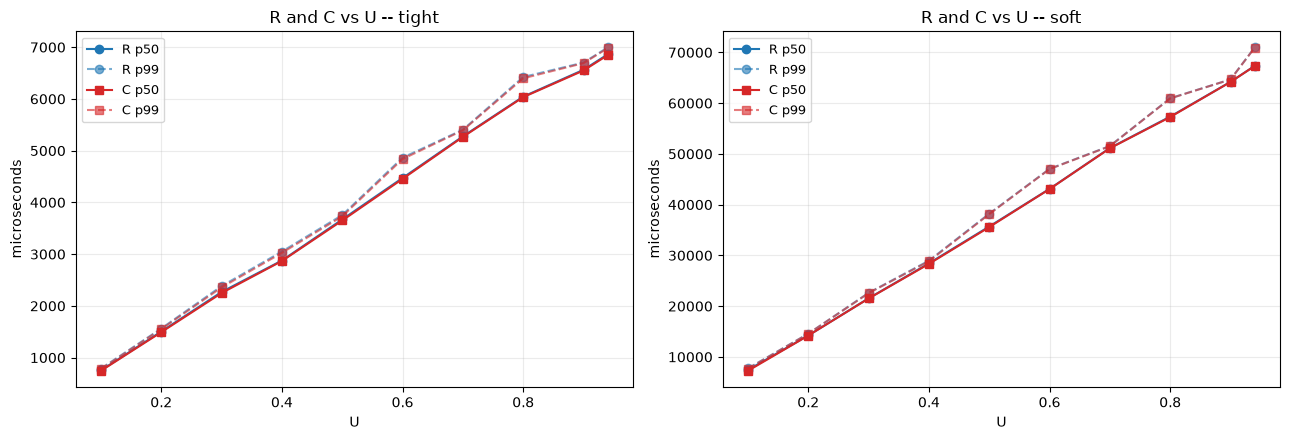

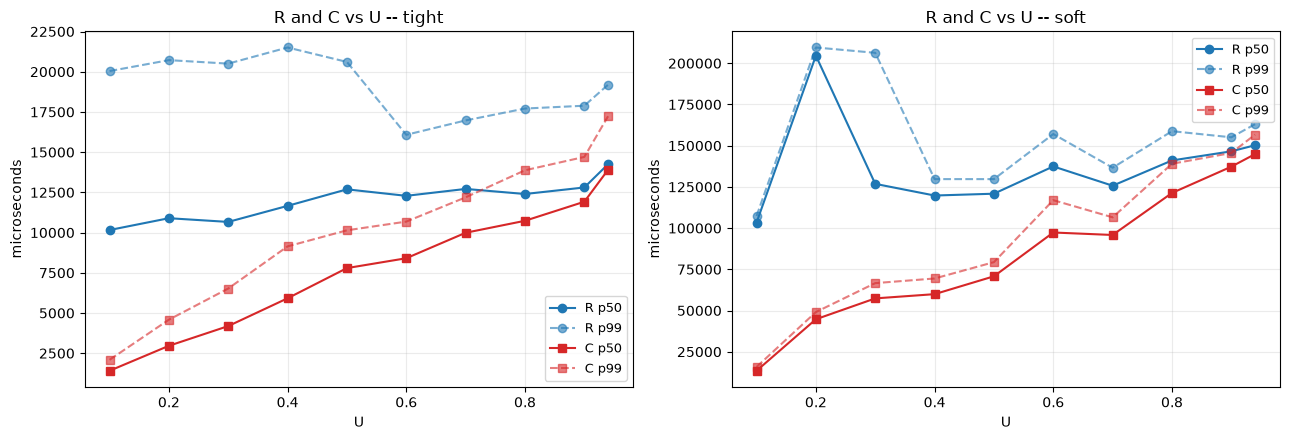

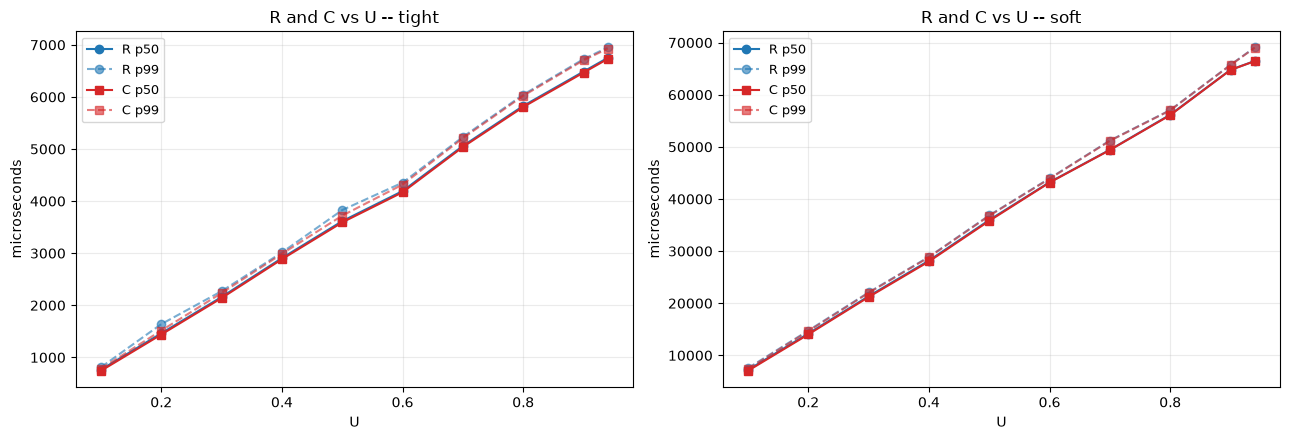

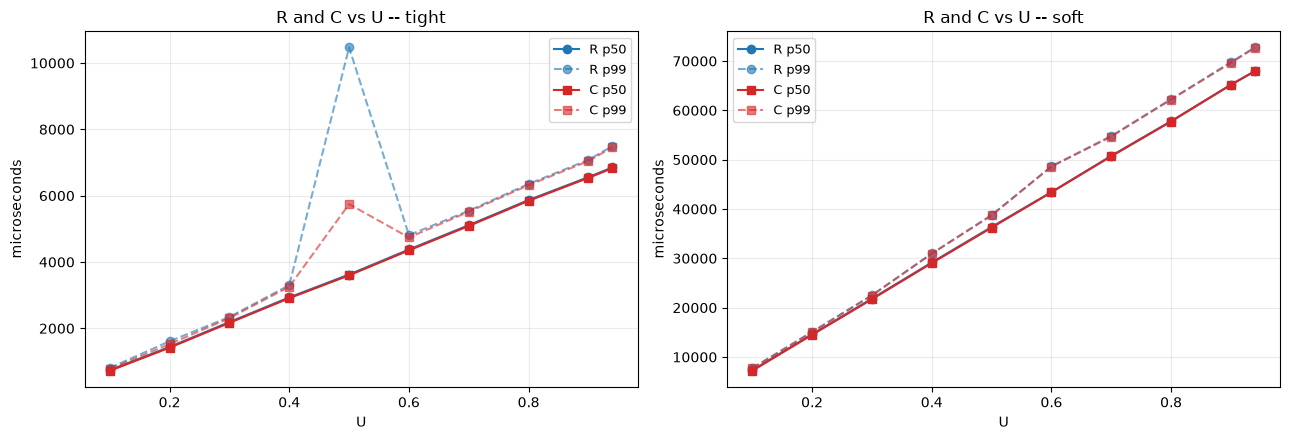

In [20]:
for m in MODELS:
    if data[m].empty: continue
    al.rc_percentiles_vs_u(data[m])